In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.ensemble import VotingRegressor, StackingRegressor
from ydata_profiling import ProfileReport

#metrics
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('bangladesh_student_performance.csv')
df

,date,gender,age,address,famsize,Pstatus,M_Edu,F_Edu,M_Job,F_Job,relationship,smoker,tuition_fee,time_friends,ssc_result,hsc_result
0,29/04/2018,M,18,Rural,GT3,Together,3,2,At_home,Farmer,No,No,71672,4,4.22,3.72
1,29/04/2018,F,19,Rural,LE3,Apart,0,4,Other,Health,Yes,No,26085,5,3.47,2.62
2,29/04/2018,F,19,Rural,GT3,Together,0,3,Teacher,Services,No,No,40891,3,3.32,2.56
3,29/04/2018,F,19,Rural,LE3,Apart,2,3,At_home,Business,No,No,50600,2,4.57,4.17
4,29/04/2018,M,17,Rural,GT3,Together,1,1,At_home,Farmer,No,No,62458,2,4.50,3.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013,29/04/2018,M,18,Urban,GT3,Together,2,2,Teacher,Health,No,No,108426,2,3.57,3.18
2014,29/04/2018,M,19,Urban,GT3,Together,0,3,Other,Teacher,Yes,No,100665,5,4.05,3.13
2015,29/04/2018,M,18,Urban,GT3,Together,3,2,Services,Farmer,Yes,No,92291,1,3.93,3.15
2016,29/04/2018,M,19,Rural,GT3,Together,0,2,At_home,Teacher,No,No,43926,3,3.34,2.83


In [6]:
profile = ProfileReport(df , title="Bangladesh student performance prediction", explorative=True)
profile.to_file('ydata.html')

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 150.79it/s]


In [7]:
# simplify
df.columns

#ydata_profiling often switches matplotlib to a non-interactive backend (Agg),
#which prevents plots from displaying in Jupyter. The code runs, but nothing shows.
%matplotlib inline


In [8]:
if 'date' in df.columns:
    df.drop(columns=['date'], inplace=True)
    
df.columns

Index(['gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu', 'F_Edu',
       'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [9]:
df.columns

Index(['gender', 'age', 'address', 'famsize', 'Pstatus', 'M_Edu', 'F_Edu',
       'M_Job', 'F_Job', 'relationship', 'smoker', 'tuition_fee',
       'time_friends', 'ssc_result', 'hsc_result'],
      dtype='object')

In [10]:
# correlations for numerical vals
corr_target = df.select_dtypes(include=np.number ).corr()['hsc_result'].sort_values(ascending=False)
corr_target


hsc_result      1.000000
ssc_result      0.950178
M_Edu           0.063776
F_Edu           0.054811
tuition_fee     0.038068
age            -0.009857
time_friends   -0.156356
Name: hsc_result, dtype: float64

In [11]:
# separate x and y
x=df.drop('hsc_result', axis=1)
y=df['hsc_result']


In [12]:
numeric_features = x.select_dtypes(include = ['int64','float64']).columns
categorical_features = x.select_dtypes(include = ['object']).columns

In [13]:
# Pipeline for numerical 
num_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
# Pipeline for categorical
cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

#combine them
preprocessor = ColumnTransformer(
    transformers= [
        ('num',num_transformer,numeric_features),
        ('cat',cat_transformer,categorical_features)
    ]
    )

In [14]:
x_train , x_test, y_train , y_test=train_test_split(
    x,y, test_size=0.2 , random_state=42
)

In [15]:
# base learner
reg_lr = LinearRegression()
reg_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
reg_gb = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)


In [16]:
# voting regressor
voting_reg = VotingRegressor(
    estimators=[
        ('lr', reg_lr),
        ('rf',reg_rf),
        ('gb', reg_gb)
    ]
)


In [17]:
# stacking
stacking_reg = StackingRegressor(
    estimators=[
        ('rf',reg_rf),
        ('gb', reg_gb)
    ],
    final_estimator=Ridge() # meta learner
)

In [18]:
# model training
#dictionary of all model
model_to_train ={
    'Linear Regression' : reg_lr,
    'Random Forest':reg_rf,
    'GradientBoosting Regressor':reg_gb,
    'Voting ensemle':voting_reg,
    'Stacking ensemble':stacking_reg
}

In [19]:
# training and evaluation 
result = []

for name,model in model_to_train.items():
    # creat fill pipeline with preprocessor
    pipe = Pipeline(
        [
            ('preprocessor', preprocessor),
            ('model',model)
        ]
    )

    # train
    pipe.fit(x_train , y_train)

    #predict
    y_pred = pipe.predict(x_test)

    #evalueate
    r2 = r2_score(y_test , y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    mse = mean_absolute_error(y_test,y_pred)


    result.append({
        'Model':name,
        'R2 score':r2,
        'RMSE':rmse,
        'MSE':mse
    })

results_df = pd.DataFrame(result).sort_values('R2 score', ascending=False)
print(results_df)

                        Model  R2 score      RMSE       MSE
4           Stacking ensemble  0.959566  0.123105  0.098696
2  GradientBoosting Regressor  0.959565  0.123107  0.098902
3              Voting ensemle  0.957528  0.126169  0.100838
1               Random Forest  0.950248  0.136556  0.108201
0           Linear Regression  0.945920  0.142371  0.111376


In [20]:
# visualization
best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_to_train[best_model_name]
best_model_obj


,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gb', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as th

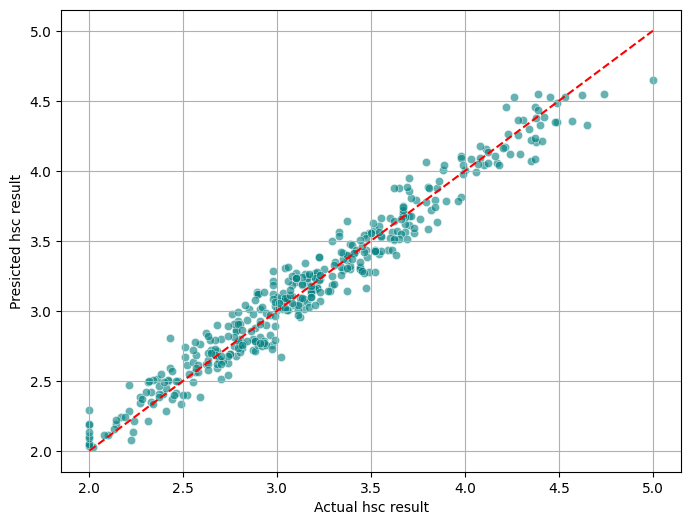

In [21]:
#fit the best model
final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model',best_model_obj)
])

final_pipe.fit(x_train,y_train)
y_final_pred = final_pipe.predict(x_test)

# plot actual vs predicted
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test , y=y_final_pred , alpha=0.6 , color='teal')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel('Actual hsc result')
plt.ylabel('Presicted hsc result')
plt.grid(True)
plt.show()


# Cross valiadation 

In [22]:
from sklearn.model_selection import cross_val_score

rf_pipeline = Pipeline(
    [('preprocessor',preprocessor),
    ('model',RandomForestRegressor(n_estimators=100 , random_state=42))
    ]
)

In [23]:
# appling cv
# 5 fold cv
cv_scores = cross_val_score(rf_pipeline , x_train, y_train,cv=5 , scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)

print(cv_rmse)

[0.13825617 0.14202924 0.15369812 0.14773708 0.12940278]


In [24]:
print(cv_rmse.mean())

0.14222467953735998


In [25]:
print(cv_rmse.std())

0.00827302663832195


In [26]:
# Stacking ensemble
stacking_pipeline = Pipeline(
    [('preprocessor',preprocessor),
    ('model',stacking_reg)
    ]
)


In [27]:
cv_scores = cross_val_score(
    rf_pipeline ,
    x_train, 
    y_train,
    cv=5 , 
    scoring='neg_mean_squared_error',
    n_jobs=-1 # use all processor core , to speed it up
    )
stacking_rmse = np.sqrt(-cv_scores)

print(stacking_rmse)

[0.13825617 0.14202924 0.15369812 0.14773708 0.12940278]


# Gridsearch cv

In [28]:
rf_pipeline = Pipeline(
    [('preprocessor',preprocessor),
    ('model',RandomForestRegressor(n_estimators=100 , random_state=42))
    ]
)

In [29]:
# define the grid
param_grid = {
    'model__n_estimators': [100,200],
    'model__max_depth':[None,10,20],
    'model__min_samples_split': [2,5]
}

In [30]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

In [31]:
grid_search.fit(x_train,y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and

In [32]:
print(grid_search.best_score_)
print(grid_search.best_params_)

-0.14145800733122194
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}


# Randomized search cv

In [33]:
from scipy.stats import randint
# my_dist = randint(1,10)

# print(my_dist.rvs())
# print(my_dist.rvs())
# print(my_dist.rvs(size=5))

In [34]:
param_dist= {
    'model__n_estimators': randint(100,200),
    'model__max_depth':[None,10,20],
    'model__min_samples_split': randint(1,10)
}

In [35]:
from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

In [36]:
random_search.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': <scipy.stats....0027475486FD0>, 'model__n_estimators': <scipy.stats....00274504E5400>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-val

In [37]:
print(random_search.best_score_)
print(random_search.best_params_)

-0.14155072625931
{'model__max_depth': 10, 'model__min_samples_split': 4, 'model__n_estimators': 153}


In [38]:
# saving the model
import pickle
filename = 'random_forest_model.pkl'
with open(filename,'wb') as file:
    pickle.dump(random_search, file)

In [39]:
# using the saved model
with open( 'random_forest_model.pkl' , 'rb') as file:
    rf_loaded_model = pickle.load(file)

In [41]:
rf_loaded_model.predict(x_test)

array([3.25217566, 3.63750277, 3.68554643, 3.94368388, 4.10960754,
       3.27158235, 4.10672961, 2.50820773, 2.10119594, 3.27213898,
       3.55110274, 2.93157534, 3.18754919, 4.49731314, 3.01887188,
       2.63947064, 3.6187843 , 3.37127854, 2.86934744, 2.90086426,
       2.74196586, 3.18972087, 2.8980331 , 3.23677595, 2.05311053,
       2.6443934 , 3.20634366, 4.04994345, 3.1101105 , 4.10614764,
       2.4519876 , 3.82105754, 4.50282826, 2.55967428, 3.19082596,
       3.21745784, 2.72664627, 3.56658287, 2.44956627, 2.60973283,
       2.98042292, 2.97680283, 3.66610802, 2.75704532, 2.32264497,
       3.02230997, 2.61599275, 2.69965718, 4.09875078, 3.23012511,
       2.98921733, 3.40357354, 4.24862065, 3.533008  , 2.9885489 ,
       3.23319113, 3.24638979, 2.78028614, 3.70008872, 2.6822246 ,
       3.03380596, 2.65618046, 2.52201913, 4.42470392, 2.57895891,
       3.20763886, 3.85548011, 2.73775452, 3.03802355, 3.23297243,
       3.01793689, 2.63008095, 2.72077347, 3.43885787, 3.05103

array([80.])